# Brain Connectivity Analysis

Load precision matrices (`iC`) and covariance matrices (`C`) for 4 methods. Nodes are grouped by anatomical position (Posterior / Central / Anterior / Midline) and permuted so groups are contiguous.

In [1]:
import os

# Must be set before any numerical library is imported
os.environ["OPENBLAS_NUM_THREADS"]   = "1"
os.environ["OMP_NUM_THREADS"]        = "1"
os.environ["MKL_NUM_THREADS"]        = "1"       # If using Intel MKL
os.environ["NUMEXPR_NUM_THREADS"]    = "1"   # If using NumExpr
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  # macOS Accelerate framework

# For Latex (get path from `which latex`)
latex_path = "/Library/TeX/texbin"
os.environ["PATH"] = latex_path+":" + os.environ["PATH"]

import numpy as np
import scipy as sp
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal,norm
from collections import defaultdict
import warnings
import sklearn.exceptions
from scipy.special import erfinv
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm.notebook import tqdm
from types import SimpleNamespace
import pickle
import plotly.graph_objects as go
import nibabel as nib
import math

from _util import *

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
})

np.set_printoptions(edgeitems=30, linewidth=100000, formatter=dict(float=lambda x: "%.3g" % x))
make_plot = lambda n,m,s=[1,1],sharex=False, sharey=False: plt.subplots(n,m,figsize=(m*3*s[0],n*2.5*s[1]),squeeze=False,layout='tight',sharex=sharex, sharey=sharey)

# Data Prep

In [2]:
# load data
# Label cortical parcels 0 to 360 with 0, and subcortical 360 to 718 with ones

labels_df=pd.read_csv("./data/fMRI/CortexSubcortex_ColeAnticevic_NetPartition_wSubcorGSR_parcels_LR_LabelKey_grouped.csv")
labels=labels_df["Group"].to_numpy().copy()
labels[(labels == 0) | (labels == 1)] = 0 # left & right cortex
labels[labels == 2] = 1 # subcortex
labels_df['group_map'] = labels

loc = pickle.load(open("./data/fMRI/xyz.pkl", "rb"))["coord"]
pconn_img = nib.load('./data/fMRI/CortexSubcortex_ColeAnticevic_NetPartition_wSubcorGSR_CovarianceMatrix.pconn.nii') # <- PATH OF MATRIX, load nib package
S_true = pconn_img.get_fdata().astype(np.float64)
p = S_true.shape[0]
print(f"Matrix shape: {S_true.shape}")
Y = make_samples(cov=S_true, mean=None, n=int(p),seed=0)

group_names = {
    0: "Cortex",
    1: "Subcortex",
}
# Color range for plotly
colors = ['red', 'black']

Matrix shape: (718, 718)


# Estimation

In [3]:
import os
import pickle
from functools import partial

iC       = {}
C        = {}
nll      = {}
runtimes = {}

folder = "fMRI"
os.makedirs(f"./results/{folder}", exist_ok=True)

jobs = {
    "aquic-1": partial(compute_aquic, Y, c=1),
    "aquic-5": partial(compute_aquic, Y, c=5),
    "aquic-30": partial(compute_aquic, Y, c=30),
    "cv-glasso": partial(compute_glasso_cv, Y),
    "cv-quic": partial(compute_quic_cv, Y),
    "tiger": partial(compute_tiger, Y),
    "clime": partial(compute_clime, Y),
}

def run_method(name, func, folder, Y):
    path = f"./results/{folder}/{name}.pkl"

    if os.path.exists(path):
        with open(path, "rb") as f:
            res = pickle.load(f)
    else:
        res = func()
        with open(path, "wb") as f:
            pickle.dump(res, f)

    temp = -1.0 * sklearn.utils.extmath.fast_logdet(res.iC) + np.trace(res.iC @ S_true)  

    return res.iC, res.C, res.runtime, temp

for name, func in jobs.items():
    iC[name], C[name], runtimes[name],nll[name] = run_method(name, func, folder, Y)

methods = list(iC.keys())

## Partitioning and table of results

Using METIS to a bipartition of the brain.

In [4]:
import os                                                   
os.environ['METIS_DLL'] = '/opt/homebrew/lib/libmetis.dylib'

import networkx as nx
import metis
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from networkx.algorithms.community.quality import modularity, partition_quality
from scipy.optimize import linear_sum_assignment

k                   = len(group_names.keys())
records             = {}
all_clabels_matched = {}
clabels_set         = {}
A_set               = {}

for m in methods:

    D   = np.diag(1.0 / np.sqrt(np.diag(iC[m])))
    iCn =  D @ iC[m] @ D

    # the adjacency matrix A is the  abs( negative values of precision matrix )
    A = np.abs(np.minimum(iCn, 0.0))
    np.fill_diagonal(A, 0.0)

    A_set[m] = A.copy()

    G = nx.from_numpy_array(A)
    _, clabels = metis.part_graph(G, nparts=k, ubvec=[1.05],recursive=False, objtype='cut')
    clabels    = np.asarray(clabels, dtype=int)

    clabels_set[m]=clabels

    communities = [set(np.where(clabels == c)[0]) for c in range(k)]
    modularity_val = modularity(G, communities, weight="weight")

    # for each community, find the most common label_group value as the matched group
    comm_to_group = {}
    used = np.zeros(k,dtype=bool) # track already assigned groups, no double assigment                                          
    counts = []
    np.random.seed(seed=0)
    for x in range(k):
        idx                     = np.where(clabels == x)[0] # indices of nodes in community x
        vals                    = labels[idx] # their true group labels
        count_k                 = np.bincount(vals, minlength=k) + np.random.rand() #add random [0,1] so there are not ties
        counts.append(count_k)

    # counts_mat[i,j] is the number of correct classification if community "i" was mapped to group "j"
    counts_mat = np.array(counts)
    row_ind, col_ind = linear_sum_assignment(counts_mat, maximize=True)
    comm_to_group={}
    for x in range(k): 
        comm_to_group[row_ind[x]] = col_ind[x]

    clabels_matched        = np.array([comm_to_group[c] for c in clabels])
    all_clabels_matched[m] = clabels_matched

    # overall + per-group accuracy
    accuracy = (clabels_matched == labels).mean()

    records[m] = {
        'nnz/row iC':  round(np.count_nonzero(iCn) / iCn.shape[0], 1),
        'nnz/row A':   round(np.count_nonzero(A) / A.shape[0], 1),
        'modularity':  round(modularity_val, 3),
        'accuracy':    round(accuracy, 3),
        'nll(x1E3)':   round(nll[m]/1000, 3),
        'runtime':     round(runtimes[m], 3),
    }

pd.DataFrame(records).T

,nnz/row iC,nnz/row A,modularity,accuracy,nll(x1E3),runtime
aquic-1,14.0,12.8,0.365,0.721,7.123,0.939
aquic-5,15.7,14.1,0.378,0.741,7.114,1.261
aquic-30,20.6,17.7,0.365,0.680,7.101,2.286
cv-glasso,7.6,6.6,0.020,0.514,7.191,52.595
cv-quic,49.4,33.2,0.269,0.535,7.089,64.951
tiger,8.6,7.4,0.413,0.657,7.188,16633.315
clime,13.8,11.4,0.375,0.702,7.181,13484.435


## Visualizations
Four cells

1. True partition of cortex and sub-cortex, spatial visualization
2. `log|iC|` (precision) and `log|C|` (covariance) for each method. Red lines mark group boundaries.
3. Paper figures
4. Spatial visualization of the partitioning of all considered estimators

In [5]:
# 3D plot
fig_gt = go.Figure()
for g in sorted(group_names.keys()):
    mask = labels == g
    fig_gt.add_trace(go.Scatter3d(
        x=loc[mask, 0], y=loc[mask, 1], z=loc[mask, 2],
        mode='markers',
        marker=dict(size=3, color=colors[g], opacity=0.8),
        name=group_names[g],
    ))

axis_off = dict(showticklabels=False, showgrid=False, zeroline=False, showbackground=False)
fig_gt.update_layout(
    title="True brain parcellation (label_group)",
    height=700, width=900,
    margin=dict(l=0, r=0, t=40, b=0),
    legend_title_text="Group",
    scene=dict(xaxis=axis_off, yaxis=axis_off, zaxis=axis_off),
)
fig_gt.show()

/opt/homebrew/lib/python3.12/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


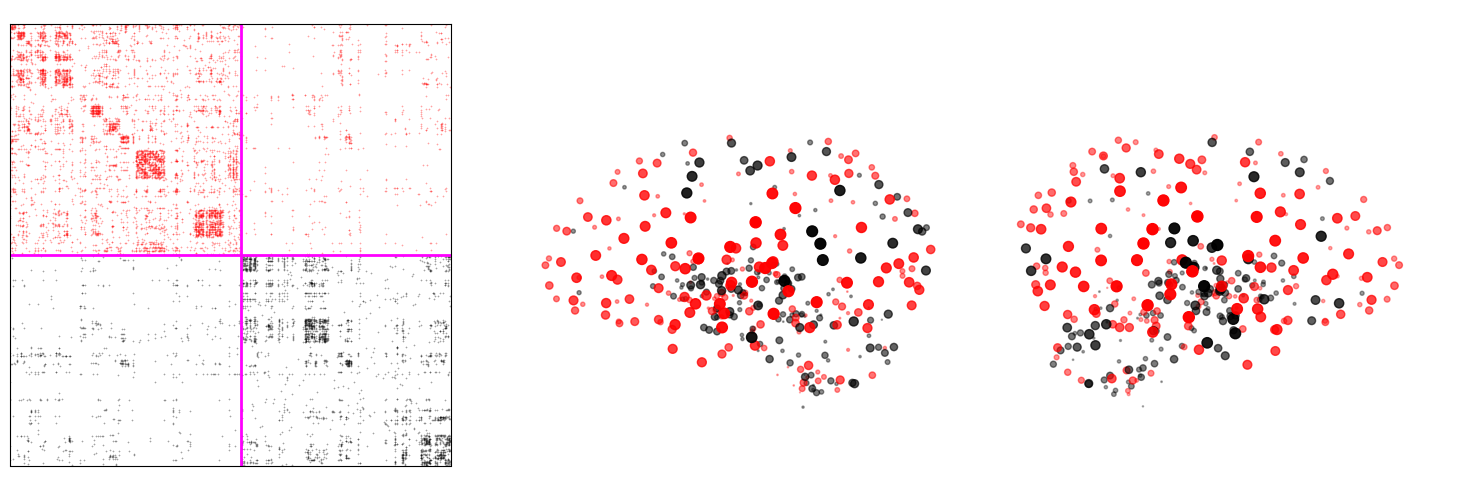

In [ ]:
fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[0.3, 0.7/2, 0.7/2], wspace=0)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], projection='3d')
ax2 = fig.add_subplot(gs[0, 2], projection='3d')

meth_sel = "aquic-5"
inx = all_clabels_matched[meth_sel]
A = A_set[meth_sel]

# adjacency matrix sorted by community
perm = np.argsort(inx)
A_sorted = A[np.ix_(perm, perm)]
inx_sorted = inx[perm]
split = np.sum(inx_sorted == 0)

A_red = A_sorted.copy(); A_red[inx_sorted != 0, :] = 0
A_black = A_sorted.copy(); A_black[inx_sorted == 0, :] = 0

ax0.spy(A_red, markersize=0.1, color='red')
ax0.spy(A_black, markersize=0.1, color='black')
ax0.axvline(x=split - 0.5, color='magenta', linewidth=2.)
ax0.axhline(y=split - 0.5, color='magenta', linewidth=2.)
ax0.set_xticks([]); ax0.set_yticks([])

# brain hemispheres
centers = loc.copy()
hemisphere_map = {'L': 0, 'R': 1, 'LR': 0}
hmask = labels_df['HEMISPHERE'].map(hemisphere_map).to_numpy(dtype=bool)
colors_inx = np.where(inx == 0, 'red', 'black')

def plot_brain(ax, mask, elev, azim, flip=1):
    sizes = (centers[mask, 0] * flip) ** 1.0
    ax.scatter(centers[mask, 0], centers[mask, 1], centers[mask, 2], c=colors_inx[mask], s=sizes)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim3d(-60, 60); ax.set_ylim3d(-70, 60); ax.set_zlim3d(-40, 80)
    ax.set_axis_off()

plot_brain(ax1, ~hmask, 0, 180, -1)
plot_brain(ax2, hmask, 0, 0, 1)

fig.tight_layout()

plt.savefig("fig_brain.png", dpi=300)


In [7]:


k = len(group_names.keys())
n_methods = len(methods)
n_cols    = math.ceil(math.sqrt(n_methods))
n_rows    = math.ceil(n_methods / n_cols)

specs = [[{'type': 'scatter3d'} for _ in range(n_cols)] for _ in range(n_rows)]
fig = make_subplots(
    rows=n_rows, cols=n_cols,
    specs=specs,
    subplot_titles=methods + [''] * (n_rows * n_cols - n_methods),
    horizontal_spacing=0.01,
    vertical_spacing=0.02,
)

for i, m in enumerate(methods):
    r, c = i // n_cols + 1, i % n_cols + 1
    cl   = all_clabels_matched[m]
    for g in range(k):
        mask = cl == g
        fig.add_trace(go.Scatter3d(
            x=loc[mask, 0], y=loc[mask, 1], z=loc[mask, 2],
            mode='markers',
            marker=dict(size=3, color=colors[g], opacity=0.8),
            name=group_names[g],
            legendgroup=group_names[g],
            showlegend=(i == 0),
        ), row=r, col=c)

axis_off = dict(showticklabels=False, showgrid=False, zeroline=False, showbackground=False)

fig.update_layout(
    height=300 * n_rows + 60,
    width=300 * n_cols,
    margin=dict(l=0, r=0, t=30, b=60),
    legend=dict(
        orientation='h',
        yanchor='top',
        y=-0.02,
        xanchor='center',
        x=0.5,
        title_text='Group',
    ),
)
for idx in range(1, n_rows * n_cols + 1):
    scene = f"scene{'' if idx == 1 else idx}"
    fig.update_layout(**{scene: dict(xaxis=axis_off, yaxis=axis_off, zaxis=axis_off)})

fig.show()